In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import Point, LineString, Polygon, MultiPoint, mapping
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import plotly.express as px

In [31]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [32]:
df = pd.read_csv("dravidian-mother-tongues-main-n-level.csv")
df = df.dropna()
df

,Mother tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Malayalam,34776533,16681977,18094556,17355542,8339365,9016177,17420991,8342612,9078379
1,Tamil,68888839,34531580,34357259,35530671,17829882,17700789,33358168,16701698,16656470
2,Telugu,80912459,40549767,40362692,53738513,26918237,26820276,27173946,13631530,13542416
3,Kannada,43506272,22014001,21492271,30614889,15462374,15152515,12891383,6551627,6339756
4,Tulu,1841963,899059,942904,1081821,525977,555844,760142,373082,387060


In [33]:
df.columns

Index(['Mother tongue', 'Total_P', 'Total_M', 'Total_F', 'Rural_P', 'Rural_M',
       'Rural_F', 'Urban_P', 'Urban_M', 'Urban_F'],
      dtype='str')

In [26]:
### Nation-level Plotting

In [ ]:
### Total Mother Tongue Speakers

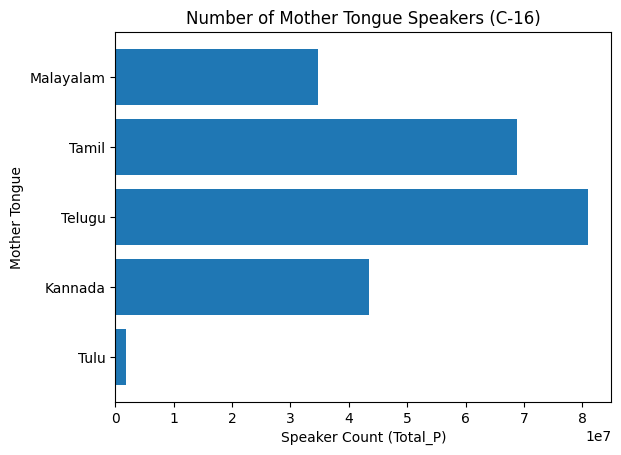

In [35]:
fig, ax = plt.subplots()

# Example data
ax.barh(
    df["Mother tongue"],
    df["Total_P"]
)
ax.set_ylabel("Mother Tongue")
ax.set_xlabel("Speaker Count (Total_P)")
ax.set_title("Number of Mother Tongue Speakers (C-16)")
ax.invert_yaxis()

plt.show()

In [18]:
# for the langoid CSV file 
df = pd.read_csv("glottolog_languoid.csv/languoid.csv") 
df.head() 

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [19]:
df.columns

Index(['id', 'family_id', 'parent_id', 'name', 'bookkeeping', 'level',
       'latitude', 'longitude', 'iso639P3code', 'description',
       'markup_description', 'child_family_count', 'child_language_count',
       'child_dialect_count', 'country_ids'],
      dtype='str')

In [20]:
tamil = df[df["name"] == "Tamil"]
tamil

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
22917,tami1289,drav1251,tami1300,Tamil,False,language,10.520219,78.825989,tam,NaN,NaN,0,0,18,IN LK


In [21]:
malayalam = df[df["name"] == "Malayalam"]
malayalam

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
13316,mala1464,drav1251,mala1541,Malayalam,False,language,9.59208,76.7651,mal,NaN,NaN,0,0,13,IN


In [22]:
tamil_longitude_val = tamil["longitude"].iloc[0]
tamil_latitude_val = tamil["latitude"].iloc[0]
# created a geometric object in coordinate space 
tamil_point = Point(tamil_longitude_val, tamil_latitude_val)

In [23]:
type(tamil_point)

shapely.geometry.point.Point

In [24]:
## need to put the point into a geodataframe 
tamil_gdf = gpd.GeoDataFrame(
    {
        "name": ["Tamil"],
        "iso": ["tam"],
        "geometry": [tamil_point]
    },
    crs="EPSG:4326"
)

In [48]:
### NOW TO GET A POLYGON LAYER (INDIA) 
india_states = gpd.read_file("gadm41_IND_shp/gadm41_IND_1.shp") 
india_states.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,NA,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,IN-AP,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,IN-AR,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,NA,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,IN-AS,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


## State Level Plotting

In [38]:
### State Level Graphs
state_df = pd.read_csv("dravidian-mother-tongues-main-state-level.csv")
state_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Kerala,Malayalam,32393324,15482417,16910907,16848670,8082073,8766597,15544654,7400344,8144310
1,Karnataka,Malayalam,745903,374572,371331,312494,155400,157094,433409,219172,214237
2,Tamil Nadu,Malayalam,718977,347788,371189,104745,51089,53656,614232,296699,317533
3,Maharashtra,Malayalam,365140,187005,178135,14444,7890,6554,350696,179115,171581
4,NCT of Delhi,Malayalam,87718,44258,43460,147,68,79,87571,44190,43381
5,Andhra Pradesh,Malayalam,61108,29648,31460,8378,3814,4564,52730,25834,26896
6,Kerala,Tamil,498938,257186,241752,342679,174405,168274,156259,82781,73478
7,Karnataka,Tamil,2101032,1062389,1038643,328485,167600,160885,1772547,894789,877758
8,Tamil Nadu,Tamil,63743847,31913539,31830308,34087554,17096202,16991352,29656293,14817337,14838956
9,Maharashtra,Tamil,484726,250731,233995,11104,6154,4950,473622,244577,229045


In [50]:
india_states["NAME_1"].unique()

<StringArray>
[   'Andaman and Nicobar',         'Andhra Pradesh',      'Arunachal Pradesh',
                  'Assam',                  'Bihar',             'Chandigarh',
           'Chhattisgarh', 'Dadra and Nagar Haveli',          'Daman and Diu',
                    'Goa',                'Gujarat',                'Haryana',
       'Himachal Pradesh',      'Jammu and Kashmir',              'Jharkhand',
              'Karnataka',                 'Kerala',            'Lakshadweep',
         'Madhya Pradesh',            'Maharashtra',                'Manipur',
              'Meghalaya',                'Mizoram',               'Nagaland',
           'NCT of Delhi',                 'Odisha',             'Puducherry',
                 'Punjab',              'Rajasthan',                 'Sikkim',
             'Tamil Nadu',              'Telangana',                'Tripura',
          'Uttar Pradesh',            'Uttarakhand',            'West Bengal']
Length: 36, dtype: str

In [49]:
india_states[["NAME_1", "geometry"]].head()

,NAME_1,geometry
0,Andaman and Nicobar,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,Andhra Pradesh,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,Arunachal Pradesh,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Arunachal Pradesh,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,Assam,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


### Malayalam 

In [44]:
malayalam_df = state_df[state_df["Mother Tongue"] == "Malayalam"]
malayalam_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,Kerala,Malayalam,32393324,15482417,16910907,16848670,8082073,8766597,15544654,7400344,8144310
1,Karnataka,Malayalam,745903,374572,371331,312494,155400,157094,433409,219172,214237
2,Tamil Nadu,Malayalam,718977,347788,371189,104745,51089,53656,614232,296699,317533
3,Maharashtra,Malayalam,365140,187005,178135,14444,7890,6554,350696,179115,171581
4,NCT of Delhi,Malayalam,87718,44258,43460,147,68,79,87571,44190,43381
5,Andhra Pradesh,Malayalam,61108,29648,31460,8378,3814,4564,52730,25834,26896


In [46]:
## Plotting Total_P on Choropleth map

In [51]:
## Merging Malayalam data with india_states 
mal_map = india_states.merge(malayalam_df, left_on="NAME_1", right_on="State_UT", how="left")
mal_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Malayalam,61108.0,29648.0,31460.0,8378.0,3814.0,4564.0,52730.0,25834.0,26896.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
mal_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Malayalam,61108.0
18,Karnataka,Malayalam,745903.0
19,Kerala,Malayalam,32393324.0
22,Maharashtra,Malayalam,365140.0
27,NCT of Delhi,Malayalam,87718.0
33,Tamil Nadu,Malayalam,718977.0


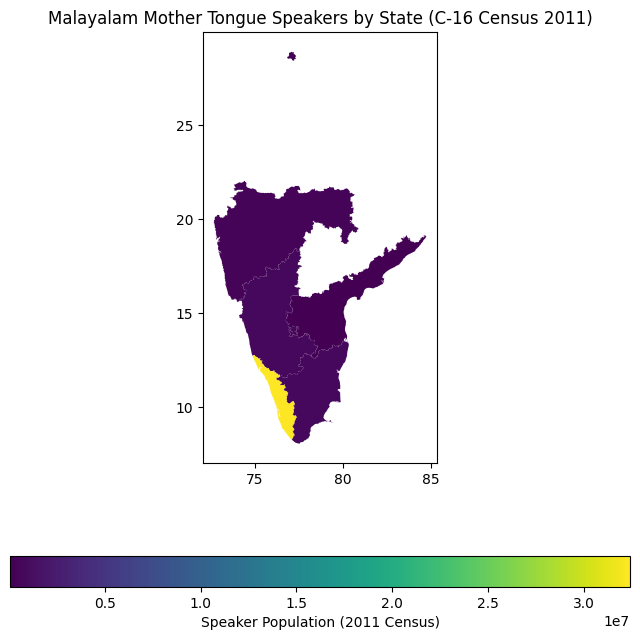

In [61]:
fig, ax = plt.subplots(figsize=(8,8))

mal_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Malayalam Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

### Tamil 

In [62]:
tamil_df = state_df[state_df["Mother Tongue"] == "Tamil"]
tamil_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
6,Kerala,Tamil,498938,257186,241752,342679,174405,168274,156259,82781,73478
7,Karnataka,Tamil,2101032,1062389,1038643,328485,167600,160885,1772547,894789,877758
8,Tamil Nadu,Tamil,63743847,31913539,31830308,34087554,17096202,16991352,29656293,14817337,14838956
9,Maharashtra,Tamil,484726,250731,233995,11104,6154,4950,473622,244577,229045
10,NCT of Delhi,Tamil,82665,42661,40004,106,62,44,82559,42599,39960
11,Andhra Pradesh,Tamil,625546,313271,312275,318459,158772,159687,307087,154499,152588


In [64]:
## Plotting Total_P on Choropleth map
## Merging Tamil data with india_states 
tamil_map = india_states.merge(tamil_df, left_on="NAME_1", right_on="State_UT", how="left")
tamil_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Tamil,625546.0,313271.0,312275.0,318459.0,158772.0,159687.0,307087.0,154499.0,152588.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
tamil_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Tamil,625546.0
18,Karnataka,Tamil,2101032.0
19,Kerala,Tamil,498938.0
22,Maharashtra,Tamil,484726.0
27,NCT of Delhi,Tamil,82665.0
33,Tamil Nadu,Tamil,63743847.0


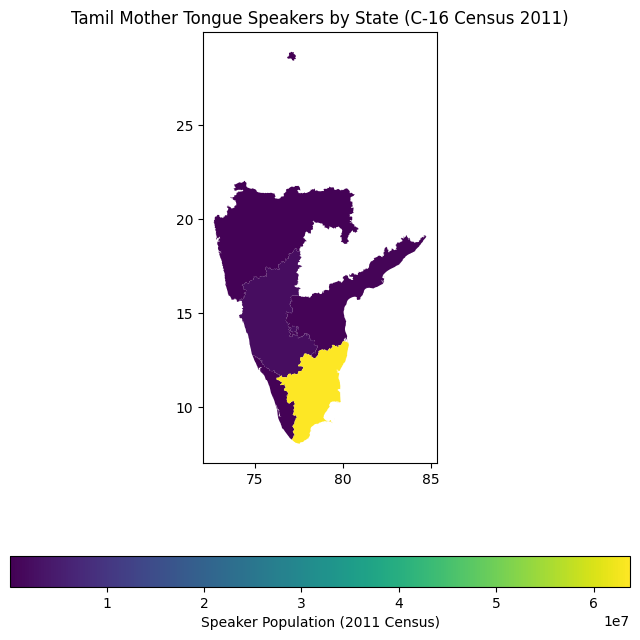

In [66]:
fig, ax = plt.subplots(figsize=(8,8))

tamil_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Tamil Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [67]:
### Telugu 

In [68]:
telugu_df = state_df[state_df["Mother Tongue"] == "Telugu"]
telugu_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
12,Kerala,Telugu,35355,18203,17152,17669,9034,8635,17686,9169,8517
13,Karnataka,Telugu,3565618,1796969,1768649,1616012,808160,807852,1949606,988809,960797
14,Tamil Nadu,Telugu,4234216,2117945,2116271,1973842,991195,982647,2260374,1126750,1133624
15,Maharashtra,Telugu,1118694,568180,550514,311977,157266,154711,806717,410914,395803
16,NCT of Delhi,Telugu,25882,13682,12200,105,51,54,25777,13631,12146
17,Andhra Pradesh,Telugu,70662838,35382930,35279908,49347283,24714317,24632966,21315555,10668613,10646942


In [71]:
## Plotting Total_P on Choropleth map
## Merging Telugu data with india_states 
telugu_map = india_states.merge(telugu_df, left_on="NAME_1", right_on="State_UT", how="left")
telugu_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Telugu,70662838.0,35382930.0,35279908.0,49347283.0,24714317.0,24632966.0,21315555.0,10668613.0,10646942.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
telugu_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Telugu,70662838.0
18,Karnataka,Telugu,3565618.0
19,Kerala,Telugu,35355.0
22,Maharashtra,Telugu,1118694.0
27,NCT of Delhi,Telugu,25882.0
33,Tamil Nadu,Telugu,4234216.0


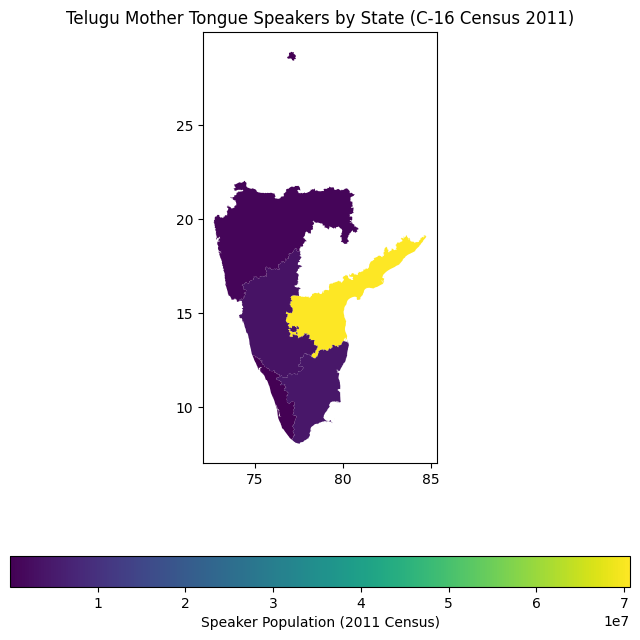

In [74]:
fig, ax = plt.subplots(figsize=(8,8))

telugu_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Telugu Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [75]:
### Kannada 

In [76]:
kannada_df = state_df[state_df["Mother Tongue"] == "Kannada"]
kannada_df

,State_UT,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
18,Kerala,Kannada,78067,39578,38489,49503,25000,24503,28564,14578,13986
19,Karnataka,Kannada,532937,259988,272949,399006,192834,206172,133931,67154,66777
20,Tamil Nadu,Kannada,1141976,572296,569680,606611,305561,301050,535365,266735,268630
21,Maharashtra,Kannada,993133,509115,484018,509508,260221,249287,483625,248894,234731
22,NCT of Delhi,Kannada,9261,4960,4301,17,9,8,9244,4951,4293
23,Andhra Pradesh,Kannada,532937,259988,272949,399006,192834,206172,133931,67154,66777


In [77]:
## Plotting Total_P on Choropleth map
## Merging Telugu data with india_states 
kannada_map = india_states.merge(kannada_df, left_on="NAME_1", right_on="State_UT", how="left")
kannada_map.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,Mother Tongue,Total_P,Total_M,Total_F,Rural_P,Rural_M,Rural_F,Urban_P,Urban_M,Urban_F
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,...,Kannada,532937.0,259988.0,272949.0,399006.0,192834.0,206172.0,133931.0,67154.0,66777.0
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
kannada_map[["NAME_1", "Mother Tongue", "Total_P"]].dropna()

,NAME_1,Mother Tongue,Total_P
1,Andhra Pradesh,Kannada,532937.0
18,Karnataka,Kannada,532937.0
19,Kerala,Kannada,78067.0
22,Maharashtra,Kannada,993133.0
27,NCT of Delhi,Kannada,9261.0
33,Tamil Nadu,Kannada,1141976.0


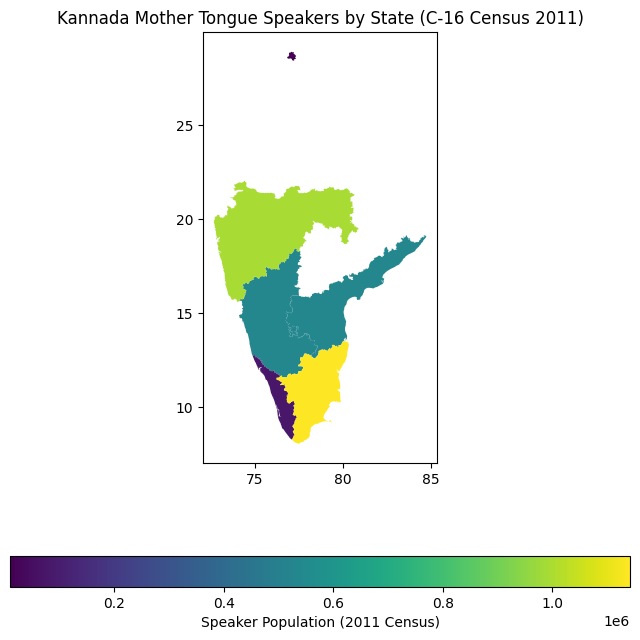

In [80]:
fig, ax = plt.subplots(figsize=(8,8))

kannada_map.plot(
    ax=ax,
    column="Total_P",
    legend=True,
    legend_kwds={"label": "Speaker Population (2011 Census)", "orientation": "horizontal"}
);

ax.set_title(
    "Kannada Mother Tongue Speakers by State (C-16 Census 2011)", 
    fontsize=12
);

In [81]:
### Making a Multiples Map Layout 

In [82]:
all_maps = [mal_map, tamil_map, kannada_map, telugu_map]

In [83]:
titles = ["Malayalam", "Telugu", "Kannada", "Telugu"]

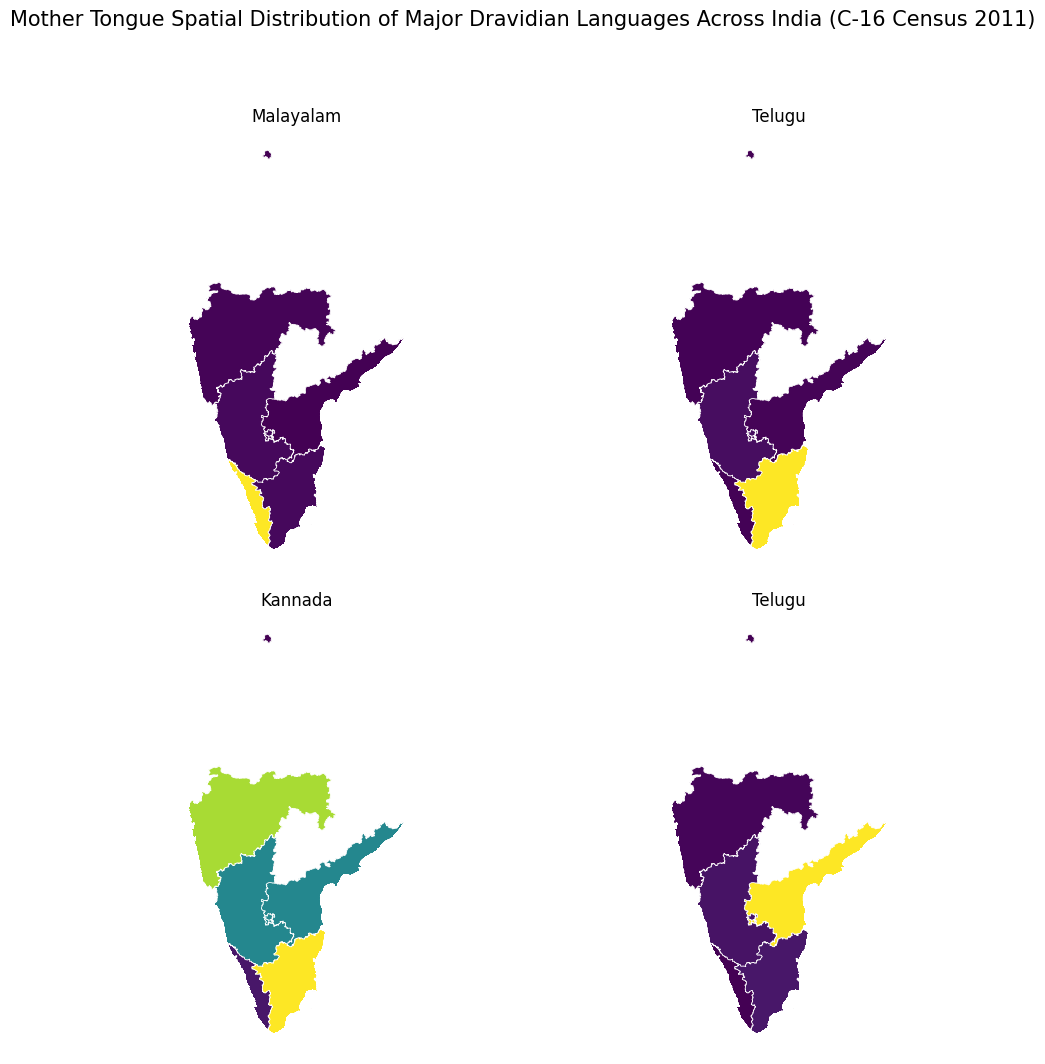

In [84]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))

for map_data, title, subplot in zip(all_maps, titles, ax.flatten()):
    
    map_data.plot(
        ax=subplot,
        column="Total_P",
        legend=False, 
        edgecolor="white",
        linewidth=0.5,
        legend_kwds={"label": "Mother Tongue Speaker Population (2011 Census)", "orientation": "horizontal"}
    
    );
    
    subplot.set_title(title);
    subplot.axis('off')

#print(type(graph))

fig.subplots_adjust(wspace=0.08, hspace=0.1)
fig.suptitle("Mother Tongue Spatial Distribution of Major Dravidian Languages Across India (C-16 Census 2011)", fontsize=15);

## adding a visual gradient

#cmap = cm.viridis
#cax = ax.

# add a ScalarMappable object 
#sm = cm.ScalarMappable(cmap=cmap)
#cbar = fig.colorbar(sm, orientation="horizontal", ax=ax, pad=0.05, ticks=None);
#cbar.set_ticks([0, 1], labels=['Low Concentration', 'High Concentration'])

#colorizer = mpl.colors.(cmap='viridis')